In [ ]:
from tigre.utilities.io import VarianDataLoader
from tigre.algorithms.single_pass_algorithms import FDK
from tigre.utilities.crop_CBCT import cropCBCT
import matplotlib.pyplot as plt
import pathlib

In [9]:
import numpy as np
from tigre.utilities.io.varian.varian_io import ScanParams, ReconParams,read_varian_geometry
from tigre.utilities.io.VarianDataLoader import load_blank_projections, load_projections, log_normalize, correct_ring_artifacts 
from tigre.utilities.io.varian.scatter import DetScattParams,correct_detector_scatter
from keras import models
from tqdm import tqdm
from skimage.transform import rescale, downscale_local_mean

In [10]:
mydir = "C:/CBCT_Scatter_Removal_Project/data/clinical/4100758/2021-07-06_101037/11528a87-b894-4239-846d-45d8fd1efeda/"

In [11]:
log_dir = pathlib.Path("C:/dev/scatter-unet/runs/20251210-141034")
keras_model = log_dir / "ckpt" / "model.keras"

In [12]:
acdc = 1
dps = 1
fasks = 0
cnn_model = models.load_model(keras_model)
max_scatt_frac = 0.95
filepath = mydir

In [13]:

scan_params = ScanParams(filepath)
recon_params = ReconParams(filepath)
if recon_params.root is None:
    recon_params = None
geometry = read_varian_geometry(scan_params, recon_params)

blank_proj_data = load_blank_projections(filepath, scan_params)

if acdc:
    angular_threshold = scan_params.calculate_angular_threshold()
    proj_data = load_projections(filepath, angular_threshold)
else:
    proj_data = load_projections(filepath)

if dps:
    dps_calib = DetScattParams(filepath)
    blank_proj_data.projs = correct_detector_scatter(blank_proj_data.projs, geometry, dps_calib)
    proj_data.projs = correct_detector_scatter(proj_data.projs, geometry, dps_calib)


Loading Varian CBCT dataset: C:/CBCT_Scatter_Removal_Project/data/clinical/4100758/2021-07-06_101037/11528a87-b894-4239-846d-45d8fd1efeda/Acquisitions


100%|██████████| 900/900 [02:57<00:00,  5.08it/s]


Performing detector point scatter correction: 


10it [00:02,  3.91it/s]


Performing detector point scatter correction: 


887it [03:45,  3.93it/s]


In [22]:
DOWN_FACTOR = 4
print("Performing CNN scatter correction: ")

input_projs = np.zeros(
    [
        proj_data.num_projs(),
        proj_data.projs.shape[1] // DOWN_FACTOR,
        proj_data.projs.shape[2] // DOWN_FACTOR,
    ]
)
output_projs = np.zeros_like(proj_data.projs)
output_blank_projs = np.zeros_like(blank_proj_data.projs)

for i, proj in tqdm(enumerate(proj_data.projs)):
    blank_interp = blank_proj_data.interp_proj(proj_data.angles[i])
    proj /= np.max(blank_interp)
    input_projs[i] = downscale_local_mean(proj, (DOWN_FACTOR, DOWN_FACTOR))

Performing CNN scatter correction: 


887it [00:08, 101.92it/s]


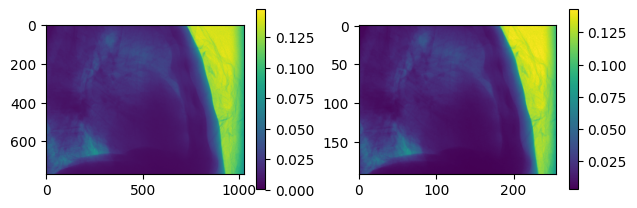

In [23]:
plt.subplot(121)
plt.imshow(proj_data.projs[0])
plt.colorbar(shrink=0.4)
plt.subplot(122)
plt.imshow(input_projs[0])
plt.colorbar(shrink=0.4)
plt.tight_layout()
plt.show()

In [24]:
input_projs = np.array(
    [np.rot90(p) for p in input_projs]
)  # NOTE: orientation should match that used in training

for i, blank_proj in enumerate(blank_proj_data.projs):
    output_blank_projs[i] = blank_proj / np.max(blank_proj)

In [25]:
print("Estimating scatter: ")
scatter_est = cnn_model.predict(input_projs)
scatter_est = np.squeeze(scatter_est)

scatter = np.zeros_like(proj_data.projs)
for i, sc in tqdm(enumerate(scatter_est)):
    sc_rot = np.rot90(sc, k=3)
    scatter[i] = rescale(sc_rot, DOWN_FACTOR, anti_aliasing=False)

scatter[scatter < 0] = 0

output_projs = proj_data.projs - np.minimum(scatter, max_scatt_frac * proj_data.projs)

Estimating scatter: 
28/28 [==============================] - 16s 588ms/step


887it [00:14, 60.04it/s]


In [28]:
proj_data.projs = output_projs
blank_proj_data.projs = output_blank_projs

In [29]:
log_projs = log_normalize(proj_data, blank_proj_data)
log_projs = correct_ring_artifacts(log_projs)

geo = geometry
angles=np.deg2rad(proj_data.angles)

Performing log normalization:


100%|██████████| 887/887 [00:16<00:00, 52.73it/s]


Performing ring artifact correction:


100%|██████████| 887/887 [01:11<00:00, 12.47it/s]


In [ ]:
log_projs,geo,angles = VarianDataLoader(mydir,acdc=1,dps=1,fasks=1,keras_model=keras_model)

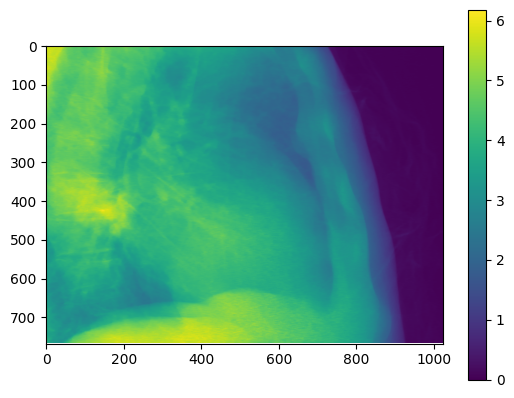

In [30]:
plt.imshow(log_projs[0])
plt.colorbar()
plt.show()

In [31]:
recon = FDK(log_projs,geo,angles)
rec = cropCBCT(recon)
rec[rec<0]=0

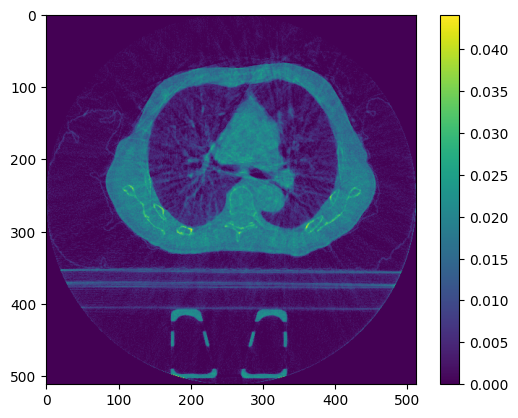

In [34]:
plt.imshow(rec[20].T)
plt.colorbar()